##Lab 7 - Gradient Boosting

###Author: Mikołaj Jędruch

#Scenario A:
We derive explicitly the optimal  𝜆 :
$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda).
$$
$$
L(y, z) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z)),
$$
where

- $y_i \in \{0,1\}$ are the binary labels,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function.

Let
$m = \sum_{i=1}^{n} y_i$ - number of ones

$k = n - m$ - number of zeros

$$
\mathcal{L}(\lambda) = -m \log(\sigma(\lambda)) - k \log(1 - \sigma(\lambda))$$
### Derivatives
$$\frac{d}{dz} \sigma(z) = \sigma(z)(1 - \sigma(z))$$
$$\frac{d}{dz} \log(\sigma(z)) = 1 - \sigma(z)$$
$$\frac{d}{dz} \log(1 - \sigma(z)) = -\sigma(z)$$

### Take the derivative
$$\frac{d\mathcal{L}}{d\lambda} = -m (1 - \sigma(\lambda)) + k \sigma(\lambda)$$
$$= -m + (m + k)\sigma(\lambda)$$
$$= -m + n \sigma(\lambda)$$
### Optimality condition
$$n \sigma(\lambda^*) = m$$
$$\sigma(\lambda^*) = \frac{m}{n}$$
### Substitute $\sigma$
$$\frac{1}{1 + e^{-\lambda^*}} = \frac{m}{n}$$

$$1 + e^{-\lambda} = \frac{n}{m}$$
$$e^{-\lambda} = \frac{n - m}{m}$$
$$\lambda = -\log\left(\frac{k}{m}\right)$$
###Finally
$$\lambda^* = \log\left(\frac{m}{k}\right)$$

### Interpretation
This is log of quotient of odds. The result is trivial and can be computed analytically.

#Scenario B:
$$\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda)$$
### Take the derivative
$$\frac{d}{d\lambda} L(y_i, f_i + \lambda) = \sigma(f_i + \lambda) - y_i$$
$$\frac{d\mathcal{L}}{d\lambda} = \sum_{i=1}^{n} \left( \sigma(f_i + \lambda) - y_i \right)$$
### Optimality condition
$$\sum_{i=1}^{n} \sigma(f_i + \lambda) = \sum_{i=1}^{n} y_i$$
$$\sum_{i=1}^{n} \sigma(f_i + \lambda) = m$$

In opposition to scenario A, here inside sigmoid function we have $f_i$ which is random, so we can't derive an explicit value. We cannot separate $\lambda$ from the equation. We have a sum of shifted sigmoids which can't be analytically simplified anymore, so we will leave it this way.

We can now calculate second derivative to check convexity.

$$\frac{d^2}{d\lambda^2} \mathcal{L}(\lambda)
= \sum_{i=1}^n \sigma(f_i + \lambda)\big(1 - \sigma(f_i + \lambda)\big)$$
We can easily see from $0<\sigma(x)< 1$ that $$\frac{d^2}{d\lambda^2} \mathcal{L}(\lambda) > 0$$

We proved that it is still convex so the optimum can be found numerically

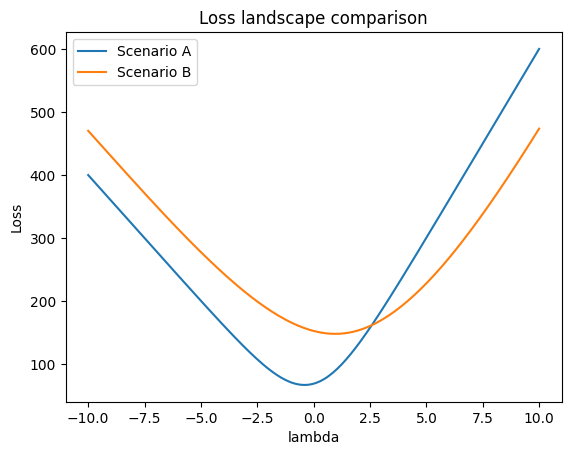

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
n = 100
m = 30
k = n - m

# predictions
f = np.random.normal(-2, 4, size=n)

arr = np.zeros(n, dtype=int)
arr[np.random.choice(n, m, replace=False)] = 1

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss_A(l):
    return -np.sum(y*np.log(sigmoid(l)) + (1-y)*np.log(1 - sigmoid(l)))

def loss_B(l):
    return -np.sum(y*np.log(sigmoid(f + l)) + (1-y)*np.log(1 - sigmoid(f + l)))

lambdas = np.linspace(-10, 10, 200)

losses_A = [loss_A(l) for l in lambdas]
losses_B = [loss_B(l) for l in lambdas]

plt.figure()
plt.plot(lambdas, losses_A, label="Scenario A")
plt.plot(lambdas, losses_B, label="Scenario B")
plt.legend()
plt.xlabel("lambda")
plt.ylabel("Loss")
plt.title("Loss landscape comparison")
plt.show()

##Final answer
Scenario B is harder than A, because it can't be computed analytically. We can find a numerical solution, because the final function is still convex, but it's obviously much more computationally heavy and will never give us the exact answer.
- Scenario B is still unimodal
- function is convex
- curvature of slope varies
- depends on distribution of randomized f functions
The problem comes from the non-linearity. Not from non-convexity or complex loss landscape.